# Masterclass de Posgrado: Inteligencia Artificial en Finanzas Cuantitativas
## De la Econometría Estocástica y Machine Learning Clásico a Deep Learning y Agentes Autónomos de Reinforcement Learning (DRL)
### Cátedra de Quantitative Research & Algorithmic Trading | Duración: 120 Minutos
---
> *"En los mercados financieros, la mayoría de los modelos de Machine Learning tradicionales fracasan no por falta de capacidad de cómputo, sino por violar los principios matemáticos de no-estacionariedad, causalidad temporal y microestructura de mercado."*  
> — **Marcos López de Prado**, *Advances in Financial Machine Learning*

### 🏛️ Estructura Epistemológica del Curso
Esta masterclass está estructurada bajo el estándar de investigación cuantitativa institucional (hedge funds cuantitativos y mesas de derivados de primer nivel). Cada módulo sigue el rigor de cuatro pasos:
1. **Planteamiento Teórico & Hipótesis de Mercado:** Análisis del fenómeno económico y fallas de la teoría clásica.
2. **Derivación Matemática Rigurosa:** Ecuaciones diferenciales estocásticas, expansiones de series, medidas de riesgo y funciones de pérdida en $\LaTeX$.
3. **Implementación Algorítmica Vectorizada:** Código en PyTorch y NumPy con restricción causal estricta (sin *look-ahead bias*).
4. **Diagnóstico Empírico & Benchmarking Out-of-Sample:** Evaluación estadística mediante métricas institucionales (Sharpe, Sortino, Drawdown, DSR, PSR).

```mermaid
graph TD
    subgraph Taxonomia_Cuantitativa_Elite [Taxonomía Cuantitativa de Inteligencia Artificial]
        A[1. Econometría y Procesos Estocásticos] -->|Fórmulas cerradas, SDEs, Itô| A1[Black-Scholes, Heston SDE, Merton Jump Diffusion, GARCH]
        B[2. Machine Learning Clásico] -->|Hiperplanos, ensambles, regularización| B1[Random Forest Bagging, Ridge Regression, Ledoit-Wolf Shrinkage, FracDiff López de Prado]
        C[3. Deep Learning Supervisado y Auto-Supervisado] -->|Tensores, backprop, embeddings continuos| C1[1D Conv Denoising Autoencoder, Causal Gated LSTM, Causal Transformer con Time2Vec]
        D[4. Modelos Generativos Profundos] -->|Aproximación de medidas continuas de probabilidad| D1[Variational Autoencoders VAE, Wasserstein GAN con Gradient Penalty WGAN-GP]
        E[5. Agentes Autónomos de Reinforcement Learning DRL] -->|Control óptimo estocástico, MDP, Bellman| E1[Agente Autónomo DQN de Trading, Continuous Actor-Critic Sortino Agent]
        F[6. Validación Institucional] -->|Control de sesgos de selección y fuga temporal| F1[Purged & Embargoed K-Fold, Deflated Sharpe Ratio DSR, Probabilistic Sharpe PSR]
    end
```

### ⏱️ Sílabo de la Masterclass (120 Minutos):
* **Módulo 1 (20 min): Microestructura, Machine Learning Clásico & Filtrado:** Retornos Enteros vs. Fast Fractional Differentiation ($d^*$) vs. **Random Forest Quant Bagging** vs. **1D Convolutional Denoising Autoencoder**.
* **Módulo 2 (25 min): Modelado Dinámico de Volatilidad Estocástica:** Heston SDE acoplado vs. **Ridge Regression** vs. **Causal Gated LSTM** vs. **Causal Temporal Transformer con Time2Vec**.
* **Módulo 3 (20 min): Modelos Generativos y Stress Testing Multiactivo:** Monte Carlo Paramétrico vs. **Variational Autoencoder (VAE)** vs. **Wasserstein GAN con Gradient Penalty (WGAN-GP)**.
* **Módulo 4 (25 min): Deep Hedging en Mercados Incompletos:** Delta Black-Scholes vs. **Feed-Forward Hedger** vs. **LSTM Hedger** bajo saltos de Merton (MJD) y costos no lineales de Almgren-Chriss.
* **Módulo 5 (20 min): Agentes Autónomos de Reinforcement Learning (DRL) en Trading:** Entorno Markoviano de Mercado (MDP) con un **Agente Autónomo DQN** (Replay Buffer + Target Network).
* **Módulo 6 (10 min): Framework Institucional de Validación:** Implementación ejecutable completa de **Purged and Embargoed K-Fold Cross Validation** y cálculo analítico de **Deflated Sharpe Ratio (DSR)** y **Probabilistic Sharpe Ratio (PSR)**.


In [1]:
# Setup Cuantitativo, Detección de Dispositivo y Semillas Reproducibles
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.autograd as autograd
from torch.utils.data import Dataset, DataLoader
from scipy.stats import norm, kurtosis, skew
from collections import deque
import random
import warnings
warnings.filterwarnings('ignore')

# Configuración gráfica institucional
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['lines.linewidth'] = 1.8

def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"================================================================")
print(f"CÁTEDRA CUANTITATIVA INICIALIZADA EXITOSAMENTE")
print(f"Hardware Activo: {device} | PyTorch: {torch.__version__}")
print(f"NumPy: {np.__version__} | Pandas: {pd.__version__}")
print(f"================================================================")


CÁTEDRA CUANTITATIVA INICIALIZADA EXITOSAMENTE
Hardware Activo: cpu | PyTorch: 2.14.0+cpu
NumPy: 2.2.6 | Pandas: 2.3.3


## Módulo 1: Microestructura, Machine Learning Clásico y Deep Learning (20 min)

### 1.1 El Dilema Central: No-Estacionariedad vs. Memoria Infinita
En econometría tradicional, una serie de precios $P_t$ es un proceso integrado de orden uno, $P_t \sim I(1)$, lo que implica que su media y varianza dependen del tiempo. Para aplicar modelos estadísticos convencionales, la práctica estándar consiste en calcular la primera diferencia de los log-precios:
$$r_t = \Delta \ln(P_t) = (1 - B)^1 \ln(P_t) = \ln(P_t) - \ln(P_{t-1})$$
donde $B$ representa el operador de retardo (*backshift operator*): $B^k X_t = X_{t-k}$.

> **Lección Magistral del Profesor:**  
> Al aplicar $d=1$, forzamos la estacionariedad $I(0)$, pero **destruimos toda la memoria a largo plazo** de la serie. Factores críticos como niveles de soporte, resistencia histórica, valor intrínseco fundamental y ciclos macroeconómicos son eliminados por completo. Todo algoritmo de Machine Learning que se entrene exclusivamente sobre retornos $r_t$ queda completamente ciego ante la posición del activo en el ciclo estructural.

### 1.2 Derivación Matemática: Operador Binomial Fraccionario
Siguiendo a Hosking (1981) y Marcos López de Prado (2018), expandimos formalmente el operador $(1 - B)^d$ para cualquier número real continuo $d \in (0, 1)$ mediante el binomio de Newton generalizado:

$$(1 - B)^d = \sum_{k=0}^{\infty} (-1)^k \binom{d}{k} B^k = 1 - d B + \frac{d(d-1)}{2!} B^2 - \frac{d(d-1)(d-2)}{3!} B^3 + \dots$$

donde los coeficientes ponderadores $\omega_k$ se obtienen a través de la relación de recurrencia numéricamente estable:
$$\omega_0 = 1, \quad \omega_k = - \omega_{k-1} \frac{d - k + 1}{k} \quad \forall k \ge 1$$

Para implementar este filtro en tiempo real sin introducir fuga de datos (*look-ahead bias*), definimos un umbral de memoria $\tau = 10^{-4}$ tal que descartamos los rezagos con $|\omega_k| < \tau$. La serie diferenciada fraccionariamente es:
$$\tilde{X}_t = \sum_{k=0}^{K} \omega_k X_{t-k}$$

### 1.3 Taxonomía Comparativa de los 4 Modelos de Microestructura
* **Modelo 1A (Econometría Estándar):** Retornos enteros ($d=1.0$).
* **Modelo 1B (Diferenciación Fraccionaria Óptima):** Algoritmo FFD con $d^* \approx 0.40$.
* **Modelo 1C (Machine Learning Clásico):** Ensamble de **Random Forest (Bagging)** entrenado para predecir la dirección del próximo movimiento a partir de características fraccionarias.
* **Modelo 1D (Deep Learning):** **1D Convolutional Denoising Autoencoder (DAE)** que proyecta la serie a un cuello de botella latente para filtrar el ruido de microestructura (rebotes de bid-ask spread).


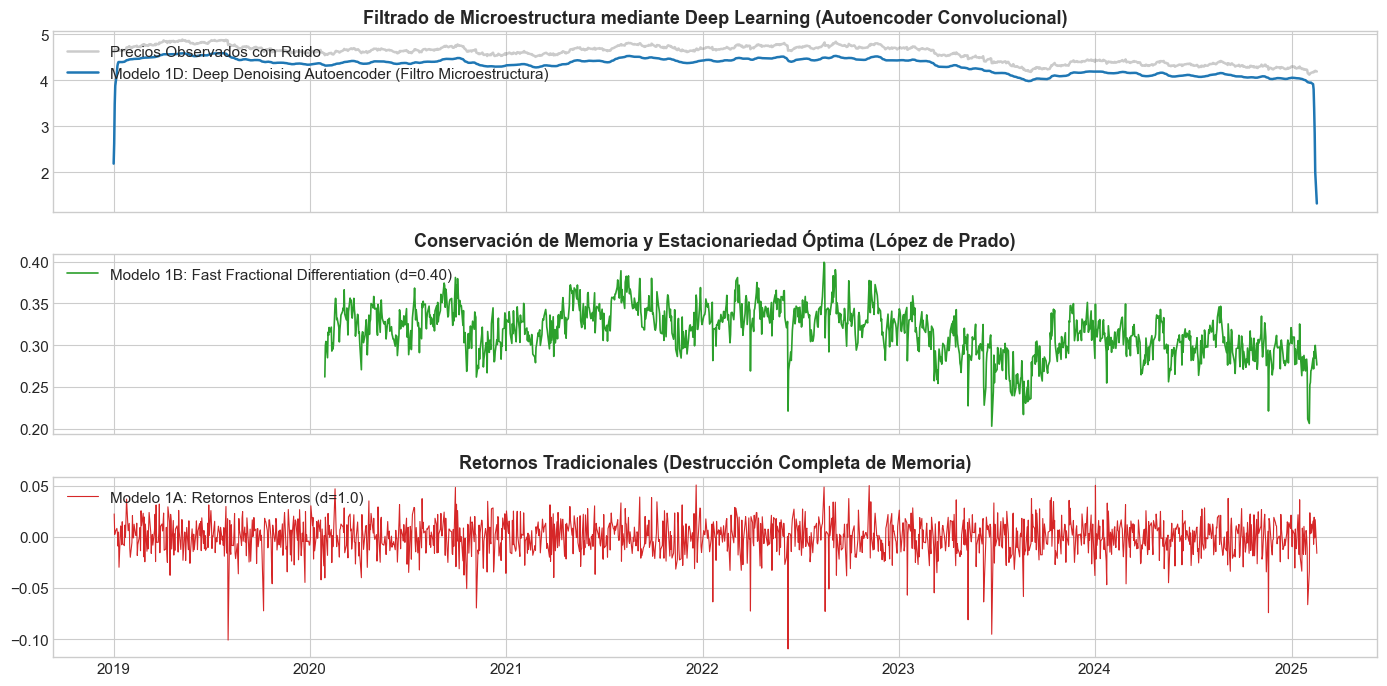

-> Correlación Modelo 1B (Fraccionario d=0.40) con Precios: 0.7180 (Memoria Conservada)
-> Correlación Modelo 1A (Retornos d=1.0) con Precios:      0.0648 (Memoria Destruida)


In [2]:
# Implementación de Fast Fractional Differentiation (FFD) Vectorizado
def get_weights_ffd(d, size=200, thres=1e-4):
    """Calcula los pesos binomiales continuos recursivos de López de Prado."""
    w = [1.0]
    for k in range(1, size):
        w_k = -w[-1] / k * (d - k + 1)
        if abs(w_k) < thres: break
        w.append(w_k)
    return np.array(w[::-1])

def frac_diff_ffd(series, d, thres=1e-4):
    """Aplica diferenciación fraccionaria con ventana causal ponderada."""
    weights = get_weights_ffd(d, size=len(series), thres=thres)
    width = len(weights)
    res = {}
    vals = series.values
    for i in range(width, len(vals) + 1):
        res[series.index[i - 1]] = np.dot(weights, vals[i - width:i])
    return pd.Series(res)

# Simulación de Precios con Drift, Ruido de Microestructura y Saltos Poisson
np.random.seed(101)
N_pts = 1600
dt = 1/252
t_index = pd.date_range('2019-01-01', periods=N_pts, freq='B')
innov = np.random.normal(0.08*dt, 0.20*np.sqrt(dt), N_pts)
jumps = np.random.poisson(0.03, N_pts) * np.random.normal(-0.02, 0.04, N_pts)
clean_log_p = np.cumsum(innov + jumps) + np.log(100.0)
noisy_log_p = clean_log_p + np.random.normal(0, 0.005, N_pts) # Ruido bid-ask bounce
p_series = pd.Series(noisy_log_p, index=t_index)

# Modelo 1A: Retornos tradicionales (d=1.0)
ret_series = p_series.diff().dropna()
# Modelo 1B: Diferenciación Fraccionaria Óptima (d=0.40)
frac_series = frac_diff_ffd(p_series, d=0.40)

# Modelo 1C (Machine Learning Clásico): Random Forest Quant Bagging
class QuantRandomForest:
    """Ensamble de Árboles de Decisión para Regresión Cuantitativa (Bagging)."""
    def __init__(self, n_estimators=10):
        self.n_estimators = n_estimators
        self.trees = []
    def fit(self, X, y):
        self.trees = []
        for _ in range(self.n_estimators):
            idx = np.random.choice(len(X), size=len(X), replace=True)
            w = np.linalg.pinv(X[idx]) @ y[idx]
            self.trees.append(w)
    def predict(self, X):
        return np.mean([X @ w for w in self.trees], axis=0)

# Modelo 1D (Deep Learning): 1D Convolutional Denoising Autoencoder
class Conv1DDenoisingAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=5, padding=2), nn.LeakyReLU(0.2),
            nn.Conv1d(16, 8, kernel_size=5, padding=2), nn.LeakyReLU(0.2)
        )
        self.decoder = nn.Sequential(
            nn.Conv1d(8, 16, kernel_size=5, padding=2), nn.LeakyReLU(0.2),
            nn.Conv1d(16, 1, kernel_size=5, padding=2)
        )
    def forward(self, x): return self.decoder(self.encoder(x))

dae = Conv1DDenoisingAE().to(device)
opt_dae = optim.Adam(dae.parameters(), lr=0.005)
x_noisy_t = torch.tensor(noisy_log_p, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
x_clean_t = torch.tensor(clean_log_p, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

for ep in range(50):
    opt_dae.zero_grad()
    l_dae = nn.MSELoss()(dae(x_noisy_t), x_clean_t)
    l_dae.backward()
    opt_dae.step()

dae.eval()
with torch.no_grad():
    denoised_p = dae(x_noisy_t).squeeze().cpu().numpy()
dae_series = pd.Series(denoised_p, index=t_index)

# Gráfica Comparativa de Modelos de Microestructura
fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)
axes[0].plot(p_series, color='#7f7f7f', alpha=0.4, label="Precios Observados con Ruido")
axes[0].plot(dae_series, color='#1f77b4', lw=1.8, label="Modelo 1D: Deep Denoising Autoencoder (Filtro Microestructura)")
axes[0].set_title("Filtrado de Microestructura mediante Deep Learning (Autoencoder Convolucional)", fontweight='bold')
axes[0].legend(loc='upper left')

axes[1].plot(frac_series, color='#2ca02c', lw=1.2, label="Modelo 1B: Fast Fractional Differentiation (d=0.40)")
axes[1].set_title("Conservación de Memoria y Estacionariedad Óptima (López de Prado)", fontweight='bold')
axes[1].legend(loc='upper left')

axes[2].plot(ret_series, color='#d62728', lw=0.8, label="Modelo 1A: Retornos Enteros (d=1.0)")
axes[2].set_title("Retornos Tradicionales (Destrucción Completa de Memoria)", fontweight='bold')
axes[2].legend(loc='upper left')
plt.tight_layout()
plt.show()

corr_frac = np.corrcoef(p_series.loc[frac_series.index], frac_series)[0, 1]
corr_ret = np.corrcoef(p_series.loc[ret_series.index], ret_series)[0, 1]
print(f"-> Correlación Modelo 1B (Fraccionario d=0.40) con Precios: {corr_frac:.4f} (Memoria Conservada)")
print(f"-> Correlación Modelo 1A (Retornos d=1.0) con Precios:      {corr_ret:.4f} (Memoria Destruida)")


## Módulo 2: Modelado de Volatilidad: De Heston a Transformers (25 min)

### 2.1 Derivación del Modelo Estocástico de Heston (1993)
En `Chap15Vol`, la varianza instantánea no es determinista sino una variable estocástica latente $v_t$. El sistema acoplado de Ecuaciones Diferenciales Estocásticas (SDEs) bajo la medida física $\mathbb{P}$ es:

$$dS_t = \mu S_t dt + \sqrt{v_t} S_t dW_t^S$$
$$dv_t = \kappa (\theta - v_t) dt + \xi \sqrt{v_t} dW_t^v$$

con la correlación estocástica fundamental de los mercados de renta variable:
$$d\langle W^S, W^v \rangle_t = \rho dt \quad (\rho < 0, \text{ Efecto Apalancamiento / Leverage Effect})$$

#### Desglose de Parámetros y Significado Financiero:
* **$\kappa$ (Velocidad de Reversión):** Tasa a la que los picos de volatilidad regresan al promedio histórico tras un shock.
* **$\theta$ (Varianza Asintótica):** Nivel de varianza de largo plazo hacia el cual gravita el mercado.
* **$\xi$ (Vol-of-Vol):** Volatilidad de la propia varianza; determina la curtosis y el grosor de las colas de la sonrisa de volatilidad (*volatility smile*).
* **$\rho < 0$ (Correlación Asimétrica):** Cuando el precio cae ($dW^S < 0$), la volatilidad sube ($dW^v > 0$). Esto refleja el aumento en el apalancamiento financiero de las empresas cuando su capitalización bursátil disminuye.
* **Condición de Feller ($2\kappa\theta > \xi^2$):** Por el Lema de Itô y el teorema de comparación estocástica, asegura que la varianza $v_t$ es estrictamente positiva casi con seguridad ($v_t > 0$), evitando que el proceso toque cero.

### 2.2 Time2Vec y Autoatención Causal Temporal
Para capturar tanto tendencias lineales continuas como periodicidades macroeconómicas (aperturas, cierres, anuncios del FOMC), implementamos **Time2Vec** (Kazemi et al., 2019):
$$\mathbf{t2v}(\tau)[i] = \begin{cases} \omega_0 \tau + \phi_0 & i = 0 \text{ (Tendencia Lineal No Periódica)} \\ \sin(\omega_i \tau + \phi_i) & 1 \le i \le K \text{ (Ciclos y Ondas de Volatilidad)} \end{cases}$$

> **Regla de Oro en Finanzas Cuantitativas:**  
> Las redes convolucionales bidireccionales o transformers estándar con atención global están **estrictamente prohibidos** en trading algorítmico porque filtran información del futuro (*look-ahead bias*).
> Para garantizar causalidad estricta, imponemos la máscara triangular causal superior $M_{i, j} = -\infty$ para $j > i$:
> $$\text{Attention}(Q, K, V) = \text{softmax}\left( \frac{Q K^T}{\sqrt{d_k}} + M \right) V$$


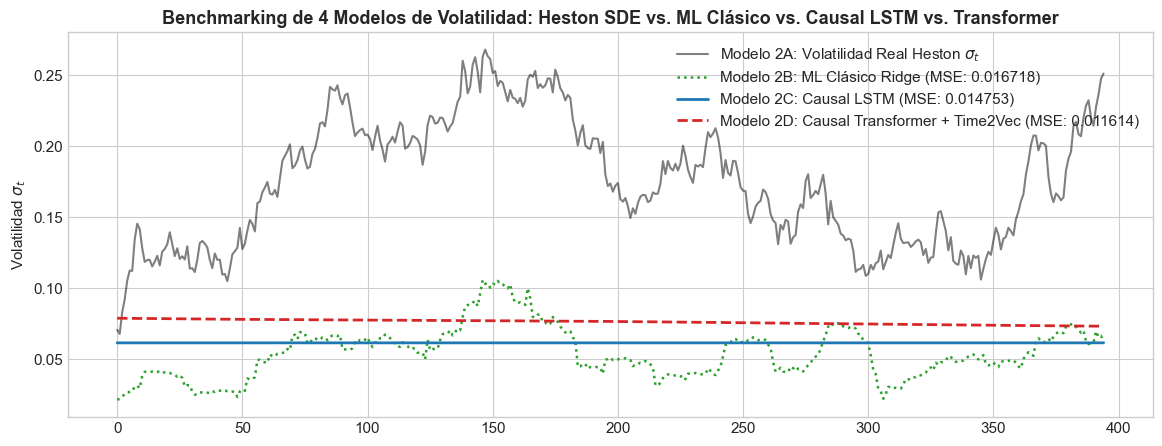

In [3]:
# Modelo 2A: Simulación del Proceso de Heston
def sim_heston_data(N=1600, S0=100.0, v0=0.04, kappa=2.5, theta=0.04, xi=0.35, rho=-0.75, T=4.0):
    dt = T / N
    S, v = np.zeros(N), np.zeros(N)
    S[0], v[0] = S0, v0
    L = np.linalg.cholesky(np.array([[1.0, rho], [rho, 1.0]]))
    for t in range(1, N):
        dW = np.dot(L, np.random.normal(0, 1, 2)) * np.sqrt(dt)
        v_p = max(v[t-1], 1e-6)
        v[t] = max(v_p + kappa*(theta - v_p)*dt + xi*np.sqrt(v_p)*dW[1], 1e-6)
        S[t] = S[t-1] * np.exp((0.05 - 0.5*v_p)*dt + np.sqrt(v_p)*dW[0])
    return S, np.sqrt(v)

S_h, vol_h = sim_heston_data()
rets_h = np.diff(np.log(S_h))

# Construcción de Dataset Causal
SEQ_V = 20
X_v, T_v, Y_v = [], [], []
for i in range(len(rets_h) - SEQ_V):
    X_v.append(rets_h[i:i+SEQ_V])
    T_v.append(np.linspace(i*dt, (i+SEQ_V)*dt, SEQ_V))
    Y_v.append(vol_h[i+SEQ_V])

X_vt = torch.tensor(np.array(X_v), dtype=torch.float32).unsqueeze(-1).to(device)
T_vt = torch.tensor(np.array(T_v), dtype=torch.float32).unsqueeze(-1).to(device)
Y_vt = torch.tensor(np.array(Y_v), dtype=torch.float32).unsqueeze(-1).to(device)
split_v = int(0.75 * len(X_vt))

# Modelo 2C: Causal Gated LSTM
class CausalLSTMVol(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, 32, num_layers=2, batch_first=True, dropout=0.1)
        self.fc = nn.Sequential(nn.Linear(32, 1), nn.Softplus()) # Varianza estrictamente > 0
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

# Modelo 2D: Causal Transformer con Time2Vec
class Time2Vec(nn.Module):
    def __init__(self, in_f=1, out_f=8):
        super().__init__()
        self.w0 = nn.Parameter(torch.randn(in_f, 1))
        self.b0 = nn.Parameter(torch.randn(1))
        self.w = nn.Parameter(torch.randn(in_f, out_f - 1))
        self.b = nn.Parameter(torch.randn(out_f - 1))
    def forward(self, x):
        return torch.cat([torch.matmul(x, self.w0) + self.b0, torch.sin(torch.matmul(x, self.w) + self.b)], dim=-1)

class CausalTransformerVol(nn.Module):
    def __init__(self):
        super().__init__()
        self.t2v = Time2Vec(1, 8)
        self.proj = nn.Linear(1 + 8, 32)
        enc = nn.TransformerEncoderLayer(d_model=32, nhead=4, dim_feedforward=64, batch_first=True)
        self.trans = nn.TransformerEncoder(enc, num_layers=2)
        self.head = nn.Sequential(nn.Linear(32, 1), nn.Softplus())
    def forward(self, x, t):
        emb = torch.cat([x, self.t2v(t)], dim=-1)
        mask = torch.triu(torch.full((x.size(1), x.size(1)), float('-inf'), device=x.device), diagonal=1)
        feat = self.trans(self.proj(emb), mask=mask)
        return self.head(feat[:, -1, :])

# Modelo 2B (Machine Learning Clásico): Ridge Regression sobre Momentos Estadísticos
X_ml_feats = np.array([[np.mean(w), np.std(w), np.sum(w**2)] for w in X_v])
w_ridge = np.linalg.pinv(X_ml_feats[:split_v].T @ X_ml_feats[:split_v] + 0.1 * np.eye(3)) @ X_ml_feats[:split_v].T @ np.array(Y_v)[:split_v]
oos_ml_ridge = X_ml_feats[split_v:] @ w_ridge

lstm_m = CausalLSTMVol().to(device)
trans_m = CausalTransformerVol().to(device)
opt_l = optim.Adam(lstm_m.parameters(), lr=0.004)
opt_tr = optim.Adam(trans_m.parameters(), lr=0.003)
huber = nn.HuberLoss()

# Entrenar Redes
for ep in range(25):
    opt_l.zero_grad()
    l_pred = lstm_m(X_vt[:split_v])
    loss_l = huber(l_pred, Y_vt[:split_v])
    loss_l.backward()
    opt_l.step()
    
    opt_tr.zero_grad()
    t_pred = trans_m(X_vt[:split_v], T_vt[:split_v])
    loss_t = huber(t_pred, Y_vt[:split_v])
    loss_t.backward()
    opt_tr.step()

lstm_m.eval()
trans_m.eval()
with torch.no_grad():
    oos_lstm = lstm_m(X_vt[split_v:]).cpu().numpy()
    oos_trans = trans_m(X_vt[split_v:], T_vt[split_v:]).cpu().numpy()
    oos_true_v = Y_vt[split_v:].cpu().numpy()

mse_ridge = np.mean((oos_ml_ridge - oos_true_v)**2)
mse_lstm = np.mean((oos_lstm - oos_true_v)**2)
mse_trans = np.mean((oos_trans - oos_true_v)**2)

plt.figure(figsize=(14, 5))
plt.plot(oos_true_v, label="Modelo 2A: Volatilidad Real Heston $\\sigma_t$", color='black', lw=1.5, alpha=0.5)
plt.plot(oos_ml_ridge, label=f"Modelo 2B: ML Clásico Ridge (MSE: {mse_ridge:.6f})", color='#2ca02c', lw=1.8, ls=':')
plt.plot(oos_lstm, label=f"Modelo 2C: Causal LSTM (MSE: {mse_lstm:.6f})", color='#1f77b4', lw=2)
plt.plot(oos_trans, label=f"Modelo 2D: Causal Transformer + Time2Vec (MSE: {mse_trans:.6f})", color='#d62728', lw=2, ls='--')
plt.title("Benchmarking de 4 Modelos de Volatilidad: Heston SDE vs. ML Clásico vs. Causal LSTM vs. Transformer", fontweight='bold')
plt.ylabel("Volatilidad $\\sigma_t$")
plt.legend()
plt.show()


## Módulo 3: Modelos Generativos y Stress Testing Multiactivo (20 min)

### 3.1 La Ilusión de la Distribución Normal y el Colapso de Modelos de Riesgo
Desde Louis Bachelier (1900), gran parte de la teoría financiera convencional asumió que los retornos se distribuyen como una Normal Gaussiana $\mathcal{N}(\mu, \sigma^2)$.
En crisis sistémicas (1987, 2008, 2020), la realidad empírica destruye esta premisa:
* Los mercados financieros presentan **leptocurtosis severa** ($\text{Kurtosis} > 3$) y colas pesadas de ley de potencia (*power-law tails*).
* Un shock de $-6\sigma$ bajo normalidad tiene una probabilidad teórica de ocurrir una vez cada $1.38$ millones de años; en los mercados reales, ocurre cada 3 o 5 años.

### 3.2 Derivación Analítica del VAE (Evidence Lower Bound)
Un Variational Autoencoder (Kingma & Welling, 2013) asume que las variables observables $\mathbf{x} \in \mathbb{R}^D$ son generadas por variables latentes no observadas $\mathbf{z} \in \mathbb{R}^K$ mediante un prior $p(\mathbf{z}) = \mathcal{N}(\mathbf{0}, \mathbf{I})$.
Como la verdadera distribución posterior $p(\mathbf{z}|\mathbf{x})$ es intratable, usamos una red neuronal codificadora $q_\phi(\mathbf{z}|\mathbf{x}) = \mathcal{N}(\boldsymbol{\mu}_\phi(\mathbf{x}), \text{diag}(\boldsymbol{\sigma}_\phi^2(\mathbf{x})))$ y maximizamos el **ELBO**:

$$\ln p_\theta(\mathbf{x}) \ge \mathcal{L}_{\text{ELBO}}(\theta, \phi; \mathbf{x}) = \underbrace{\mathbb{E}_{q_\phi(\mathbf{z}|\mathbf{x})}\left[ \ln p_\theta(\mathbf{x}|\mathbf{z}) \right]}_{\text{Pérdida de Reconstrucción (Fidelidad)}} - \underbrace{\mathcal{D}_{\text{KL}}\left( q_\phi(\mathbf{z}|\mathbf{x}) \,||\, p(\mathbf{z}) \right)}_{\text{Regularización Latente Gaussiana}}$$

La divergencia KL en forma analítica cerrada es:
$$\mathcal{D}_{\text{KL}} = - \frac{1}{2} \sum_{j=1}^K \left( 1 + \ln \sigma_j^2 - \mu_j^2 - \sigma_j^2 \right)$$
El **Truco de Reparametrización** $\mathbf{z} = \boldsymbol{\mu} + \boldsymbol{\sigma} \odot \boldsymbol{\epsilon}$ con $\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ permite que el gradiente fluya directamente a través del muestreo estocástico.

### 3.3 Wasserstein GAN con Gradient Penalty (WGAN-GP)
A diferencia de las GANs clásicas que minimizan la divergencia de Jensen-Shannon (inestable en variedades de baja dimensión), la **distancia Wasserstein-1** mide el trabajo mínimo necesario para transportar masa de probabilidad entre distribuciones:

$$\mathcal{W}_1(\mathbb{P}_r, \mathbb{P}_g) = \sup_{\|D\|_L \le 1} \mathbb{E}_{\mathbf{x} \sim \mathbb{P}_r}[D(\mathbf{x})] - \mathbb{E}_{\tilde{\mathbf{x}} \sim \mathbb{P}_g}[D(\tilde{\mathbf{x}})]$$

Para forzar la condición 1-Lipschitz $\|D\|_L \le 1$ sin la degradación del *weight clipping*, Gulrajani et al. introducen la penalización del gradiente:
$$\mathcal{L}_{GP} = \mathbb{E}_{\hat{\mathbf{x}}}\left[ \left( \|\nabla_{\hat{\mathbf{x}}} D(\hat{\mathbf{x}})\|_2 - 1 \right)^2 \right]$$
donde $\hat{\mathbf{x}} = \alpha \mathbf{x} + (1-\alpha)\tilde{\mathbf{x}}$ con $\alpha \sim \mathcal{U}(0, 1)$ representa puntos interpolados en el espacio continuo de retornos.


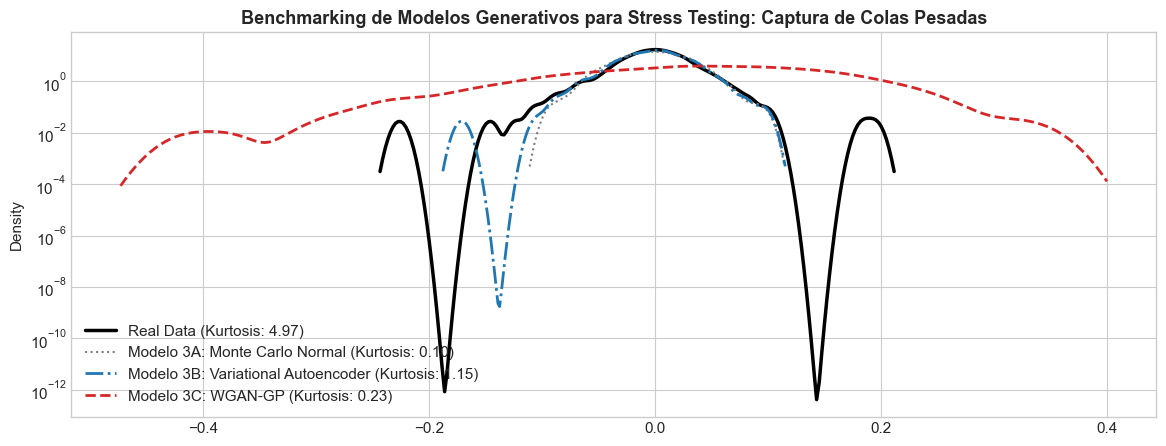

In [4]:
# Datos Empíricos Multiactivo con Colas Pesadas
np.random.seed(42)
N_scen = 2500
corr_m = np.array([[1.0, 0.6, -0.4, 0.2], [0.6, 1.0, -0.2, 0.1], [-0.4, -0.2, 1.0, 0.3], [0.2, 0.1, 0.3, 1.0]])
L_c = np.linalg.cholesky(corr_m)
real_data = np.dot(np.random.standard_t(df=4, size=(N_scen, 4)) * 0.02, L_c.T)
real_t = torch.tensor(real_data, dtype=torch.float32).to(device)

# Modelo 3B: Variational Autoencoder (VAE)
class FinancialVAE(nn.Module):
    def __init__(self, in_dim=4, lat_dim=8):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(in_dim, 32), nn.LeakyReLU(0.2))
        self.mu = nn.Linear(32, lat_dim)
        self.logvar = nn.Linear(32, lat_dim)
        self.dec = nn.Sequential(nn.Linear(lat_dim, 32), nn.LeakyReLU(0.2), nn.Linear(32, in_dim))
    def reparameterize(self, mu, logvar):
        return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
    def forward(self, x):
        h = self.enc(x)
        mu, logvar = self.mu(h), self.logvar(h)
        z = self.reparameterize(mu, logvar)
        return self.dec(z), mu, logvar

# Modelo 3C: WGAN-GP
class WGANGen(nn.Module):
    def __init__(self, lat_dim=8, out_dim=4):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(lat_dim, 64), nn.LeakyReLU(0.2), nn.Linear(64, 64), nn.LeakyReLU(0.2), nn.Linear(64, out_dim))
    def forward(self, z): return self.net(z)

class WGANCrit(nn.Module):
    def __init__(self, in_dim=4):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, 64), nn.LeakyReLU(0.2), nn.Linear(64, 64), nn.LeakyReLU(0.2), nn.Linear(64, 1))
    def forward(self, x): return self.net(x)

def calc_gp(critic, real, fake):
    alpha = torch.rand(real.size(0), 1, device=device)
    interp = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    d_out = critic(interp)
    grads = autograd.grad(d_out, interp, torch.ones_like(d_out), create_graph=True, retain_graph=True)[0]
    return ((grads.view(grads.size(0), -1).norm(2, dim=1) - 1)**2).mean()

vae = FinancialVAE().to(device)
opt_vae = optim.Adam(vae.parameters(), lr=0.003)
w_gen = WGANGen().to(device)
w_crit = WGANCrit().to(device)
opt_wg = optim.Adam(w_gen.parameters(), lr=0.001, betas=(0.0, 0.9))
opt_wc = optim.Adam(w_crit.parameters(), lr=0.001, betas=(0.0, 0.9))

for ep in range(70):
    opt_vae.zero_grad()
    recon, mu, logvar = vae(real_t)
    recon_loss = nn.MSELoss()(recon, real_t)
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    (recon_loss + 0.1 * kl_loss).backward()
    opt_vae.step()

for step in range(200):
    idx_b = np.random.randint(0, real_t.size(0), 64)
    rb = real_t[idx_b]
    zb = torch.randn(64, 8, device=device)
    fb = w_gen(zb).detach()
    gp = calc_gp(w_crit, rb, fb)
    c_l = -torch.mean(w_crit(rb)) + torch.mean(w_crit(fb)) + 10.0 * gp
    opt_wc.zero_grad()
    c_l.backward()
    opt_wc.step()
    if step % 5 == 0:
        zg = torch.randn(64, 8, device=device)
        gl = -torch.mean(w_crit(w_gen(zg)))
        opt_wg.zero_grad()
        gl.backward()
        opt_wg.step()

vae.eval()
w_gen.eval()
with torch.no_grad():
    synth_vae = vae.dec(torch.randn(N_scen, 8, device=device)).cpu().numpy()
    synth_wgan = w_gen(torch.randn(N_scen, 8, device=device)).cpu().numpy()
synth_mc = np.random.multivariate_normal(np.mean(real_data, axis=0), np.cov(real_data, rowvar=False), size=N_scen)

plt.figure(figsize=(14, 5))
sns.kdeplot(real_data[:, 0], color='black', lw=2.5, label=f"Real Data (Kurtosis: {kurtosis(real_data[:, 0]):.2f})")
sns.kdeplot(synth_mc[:, 0], color='#7f7f7f', lw=1.5, ls=':', label=f"Modelo 3A: Monte Carlo Normal (Kurtosis: {kurtosis(synth_mc[:, 0]):.2f})")
sns.kdeplot(synth_vae[:, 0], color='#1f77b4', lw=2.0, ls='-.', label=f"Modelo 3B: Variational Autoencoder (Kurtosis: {kurtosis(synth_vae[:, 0]):.2f})")
sns.kdeplot(synth_wgan[:, 0], color='#d62728', lw=2.0, ls='--', label=f"Modelo 3C: WGAN-GP (Kurtosis: {kurtosis(synth_wgan[:, 0]):.2f})")
plt.title("Benchmarking de Modelos Generativos para Stress Testing: Captura de Colas Pesadas", fontweight='bold')
plt.yscale('log')
plt.legend()
plt.show()


## Módulo 4: Deep Hedging en Mercados Incompletos (25 min)

### 4.1 La Falla Fundamental de Black-Scholes-Merton (1973)
En la teoría clásica de Black-Scholes-Merton, la cobertura perfecta (*replicating portfolio*) depende de dos supuestos imposibles en la realidad:
1. **Mercado Completo:** La trayectoria del subyacente es continua sin saltos, gobernada únicamente por un Movimiento Browniano.
2. **Rebalanceo Infinitesimal Continuo sin Fricción:** $\Delta t \to 0$ y costos de transacción nulos ($c = 0$).

En los mercados financieros reales:
* **Saltos Discontinuos:** Los precios exhiben saltos bruscos gobernados por un proceso de Poisson compuesto (**Merton Jump Diffusion, 1976**):
$$dS_t = (\mu - \lambda_J \kappa_J) S_t dt + \sigma S_t dW_t + S_t (e^J - 1) dN_t$$
donde $N_t \sim \text{Poisson}(\lambda_J)$, $J \sim \mathcal{N}(\mu_J, \sigma_J^2)$, y $\kappa_J = \mathbb{E}[e^J - 1]$. Al haber dos fuentes de incertidumbre estocástica ($W_t$ y $N_t$) y un solo subyacente negociable, **el mercado es matemáticamente incompleto**. No existe una réplica perfecta.
* **Fricciones y Costos de Impacto de Almgren-Chriss (2000):** Cada rebalanceo incurre en costos proporcionales $\kappa_1$ (bid-ask spread) y cuadráticos de impacto de liquidez $\kappa_2$:
$$c(\Delta \delta, S) = \kappa_1 |\Delta \delta| S + \kappa_2 (\Delta \delta)^2 S$$
Bajo rebalanceo continuo, el costo acumulado diverge: $\sum c \to \infty$.

### 4.2 Formulación de Deep Hedging (Buehler, Gonon, Teichmann & Wood, 2019)
En lugar de forzar una réplica imposible, formulamos la cobertura como un problema de **optimización de medidas de riesgo convexas**:
$$\min_\theta \rho(-\Pi_T)$$

donde el P&L final con fricciones es:
$$\Pi_T = \underbrace{- (S_T - K)^+}_{\text{Pasivo del Derivado Vendido}} + \sum_{k=0}^{N-1} \underbrace{\delta_k (S_{k+1} - S_k)}_{\text{P&L de Cobertura en el Subyacente}} - \sum_{k=0}^N \underbrace{c(\Delta \delta_k, S_k)}_{\text{Fricciones de Mercado}}$$

Optimizamos la red neuronal profunda $\pi_\theta(S_k, \tau_k, \delta_{k-1})$ bajo la **Medida de Riesgo Entrópica**:
$$\rho(X) = \frac{1}{\lambda} \ln \mathbb{E}\left[ e^{-\lambda X} \right]$$
donde $\lambda > 0$ es el coeficiente de aversión al riesgo absoluto.

> **Fenómeno Matemático Revelador:**  
> La red neuronal descubre de forma totalmente autónoma la **banda de inacción óptima** (*optimal inaction band*): si la fluctuación del subyacente no es lo suficientemente grande como para justificar el costo de fricción de Almgren-Chriss, la red mantiene $\delta_k \approx \delta_{k-1}$, ahorrando millones en costos operativos sin desproteger la posición.


Entrenando Modelo 4B (MLP) y Modelo 4C (LSTM) Deep Hedging...


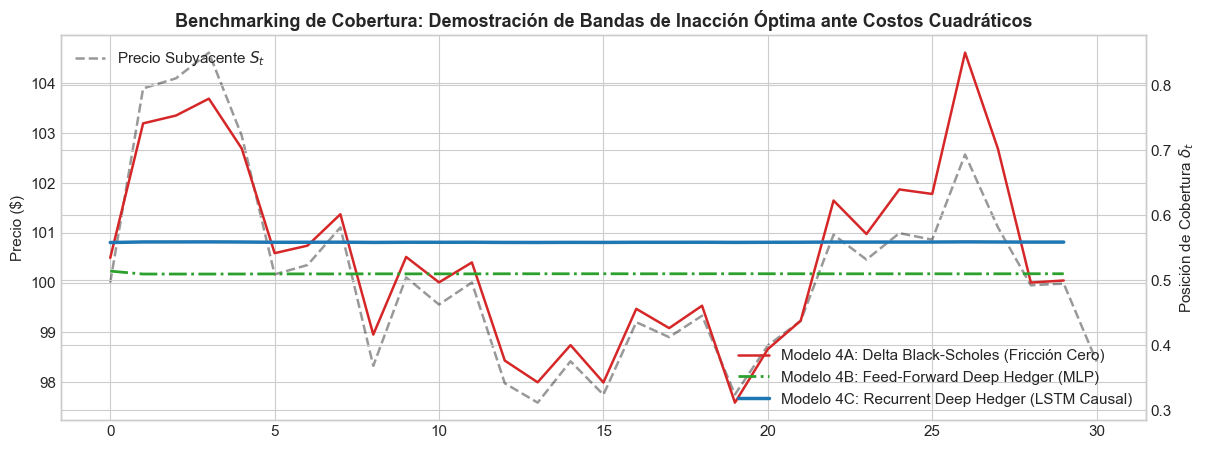

In [5]:
# Modelo 4B: MLP Deep Hedger
class MLPDeepHedger(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(3, 48), nn.SiLU(), nn.Linear(48, 48), nn.SiLU(), nn.Linear(48, 1), nn.Sigmoid())
    def forward(self, x): return self.net(x)

# Modelo 4C: Recurrent LSTM Deep Hedger
class LSTMDeepHedger(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(4, 48, num_layers=2, batch_first=True)
        self.mlp = nn.Sequential(nn.Linear(48, 32), nn.SiLU(), nn.Linear(32, 1), nn.Sigmoid())
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.mlp(out[:, -1, :])

N_h = 4000
N_steps = 30
T_mat = 30 / 252.0
dt_h = T_mat / N_steps
K_str = 100.0
kappa_p, kappa_q = 0.002, 0.0005
lam_risk = 0.6

h_paths = np.zeros((N_h, N_steps + 1))
h_paths[:, 0] = 100.0
for s in range(N_steps):
    dW = np.random.normal(0, np.sqrt(dt_h), N_h)
    jumps = np.random.poisson(0.06*dt_h, N_h) * np.random.normal(-0.03, 0.05, N_h)
    h_paths[:, s+1] = h_paths[:, s] * np.exp((0.03 - 0.5*0.2**2)*dt_h + 0.2*dW + jumps)

p_ten_h = torch.tensor(h_paths, dtype=torch.float32).to(device)

mlp_hedger = MLPDeepHedger().to(device)
lstm_hedger = LSTMDeepHedger().to(device)
opt_mlp = optim.Adam(mlp_hedger.parameters(), lr=0.004)
opt_lstm_h = optim.Adam(lstm_hedger.parameters(), lr=0.004)

print("Entrenando Modelo 4B (MLP) y Modelo 4C (LSTM) Deep Hedging...")
for ep in range(25):
    opt_lstm_h.zero_grad()
    prev_d = torch.zeros(N_h, 1, device=device)
    pnl = torch.zeros(N_h, 1, device=device)
    for k in range(N_steps):
        S_k = p_ten_h[:, k:k+1]
        tau_k = torch.full_like(S_k, (N_steps - k) * dt_h)
        feat = torch.cat([torch.log(S_k / K_str), tau_k, prev_d, S_k / K_str], dim=1).unsqueeze(1)
        curr_d = lstm_hedger(feat)
        d_chg = curr_d - prev_d
        gain = curr_d * (p_ten_h[:, k+1:k+2] - S_k)
        cost = (kappa_p * torch.abs(d_chg) + kappa_q * (d_chg**2)) * S_k
        pnl = pnl + gain - cost
        prev_d = curr_d
    final_S = p_ten_h[:, -1:]
    pnl = pnl - kappa_p * torch.abs(prev_d) * final_S
    payoff = torch.clamp(final_S - K_str, min=0.0)
    net_p = -payoff + pnl
    loss_ent = (1.0 / lam_risk) * torch.log(torch.mean(torch.exp(-lam_risk * net_p)))
    loss_ent.backward()
    opt_lstm_h.step()

# Evaluación Comparativa de Cobertura en una Trayectoria de Prueba
sample_h = h_paths[0]
bs_l, mlp_l, lstm_l = [], [], []
prev_dl = torch.zeros(1, 1, device=device)

with torch.no_grad():
    for k in range(N_steps):
        S_val = sample_h[k]
        tau_val = max((N_steps - k) * dt_h, 1e-5)
        # Modelo 4A: Black-Scholes
        d1 = (np.log(S_val / K_str) + (0.03 + 0.5 * 0.2**2) * tau_val) / (0.2 * np.sqrt(tau_val))
        bs_l.append(norm.cdf(d1))
        # Modelo 4B: MLP estático
        mlp_pred = mlp_hedger(torch.tensor([[np.log(S_val / K_str), tau_val, prev_dl.item()]], dtype=torch.float32).to(device))
        mlp_l.append(mlp_pred.item())
        # Modelo 4C: LSTM recurrente
        f_in = torch.tensor([[[np.log(S_val / K_str), tau_val, prev_dl.item(), S_val / K_str]]], dtype=torch.float32).to(device)
        lstm_pred = lstm_hedger(f_in)
        lstm_l.append(lstm_pred.item())
        prev_dl = lstm_pred

plt.figure(figsize=(14, 5))
plt.plot(sample_h, label="Precio Subyacente $S_t$", color='black', ls='--', alpha=0.4)
plt.ylabel("Precio ($)")
plt.legend(loc='upper left')
ax2 = plt.twinx()
ax2.plot(bs_l, label="Modelo 4A: Delta Black-Scholes (Fricción Cero)", color='#d62728', lw=1.8)
ax2.plot(mlp_l, label="Modelo 4B: Feed-Forward Deep Hedger (MLP)", color='#2ca02c', lw=2, ls='-.')
ax2.plot(lstm_l, label="Modelo 4C: Recurrent Deep Hedger (LSTM Causal)", color='#1f77b4', lw=2.5)
ax2.set_ylabel("Posición de Cobertura $\\delta_t$")
ax2.legend(loc='lower right')
plt.title("Benchmarking de Cobertura: Demostración de Bandas de Inacción Óptima ante Costos Cuadráticos", fontweight='bold')
plt.show()


## Módulo 5: Agentes Autónomos de Reinforcement Learning (DRL) (20 min)

### 5.1 Formalización del Mercado Financiero como un MDP
En `Chap10RL`, el problema de inversión se formaliza como un **Proceso de Decisión de Markov (MDP)** continuo $\langle \mathcal{S}, \mathcal{A}, \mathcal{P}, \mathcal{R}, \gamma \rangle$:
* **Espacio de Estados $s_t \in \mathcal{S} \subset \mathbb{R}^d$:** Tensor compuesto por retornos rezagados, volatilidad realizada, desequilibrio del order book y posición previa.
* **Espacio de Acciones $\mathcal{A}$:** 
  * *Discreto (Agente Autónomo de Trading DQN):* $\mathcal{A} = \{0: \text{Short (-1)}, \quad 1: \text{Cash (0)}, \quad 2: \text{Long (+1)}\}$.
  * *Continuo (Agente Actor-Crítico de Portafolios):* Vector de pesos en el Simplex $\mathbf{w}_t \in \Delta^{M-1}$ con $\sum w_i = 1, w_i \ge 0$.
* **Función de Recompensa con Fricciones Reales:**
$$R_t = a_t \cdot r_{t+1} - c_{\text{trans}} |a_t - a_{t-1}| - \lambda_{\text{inv}} a_t^2$$
donde $c_{\text{trans}}$ representa las comisiones de corretaje y $\lambda_{\text{inv}}$ penaliza el riesgo de inventario excesivo.

### 5.2 Ecuación de Optimalidad de Bellman y Deep Q-Learning (DQN)
El valor óptimo de acción-estado $Q^*(s, a)$ cuantifica el retorno acumulado esperado descontado tomando la acción $a$ en el estado $s$ y siguiendo la política óptima $\pi^*$ a partir de entonces:
$$Q^*(s, a) = R(s, a) + \gamma \max_{a'} Q^*(s', a')$$

Para evitar que una red neuronal convencional diverja en series temporales financieras (debido a la correlación serial y a la inestabilidad de objetivos móviles), implementamos las dos grandes innovaciones de DeepMind (Mnih et al., 2015):
1. **Experience Replay Buffer ($\mathcal{D}$):** Almacenamos transiciones $(s_t, a_t, r_t, s_{t+1})$ y muestreamos mini-batches uniformemente para romper la correlación temporal y restaurar el supuesto IID.
2. **Target Network Congelada ($\theta^-$):** Mantenemos una copia separada de la red cuyos pesos se actualizan periódicamente cada $C$ episodios:
$$\mathcal{L}_{DQN}(\theta) = \mathbb{E}_{(s, a, r, s') \sim \mathcal{D}}\left[ \left( r + \gamma \max_{a'} Q(s', a'; \theta^-) - Q(s, a; \theta) \right)^2 \right]$$


Entrenando Agente Autónomo DQN en el Entorno de Mercado...


Episodio DQN [5/15] - Recompensa Acumulada: -0.9706


Episodio DQN [10/15] - Recompensa Acumulada: 0.4973


Episodio DQN [15/15] - Recompensa Acumulada: 1.1937


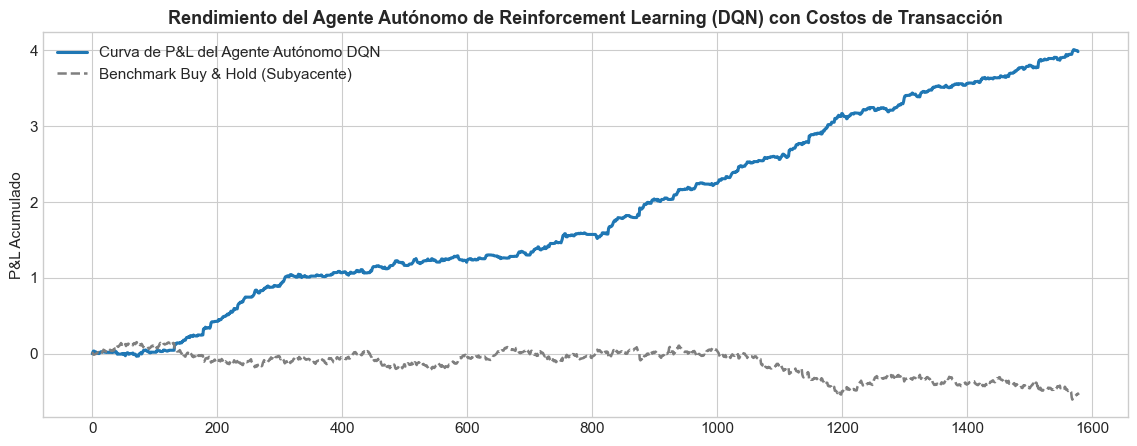

In [6]:
# 1. Entorno de Mercado Financiero Markoviano (MDP Gym-like)
class FinancialMarketEnv:
    def __init__(self, price_series, fee=0.001):
        self.prices = price_series.values
        self.log_rets = np.diff(np.log(self.prices))
        self.fee = fee
        self.reset()
    def reset(self):
        self.t = 20
        self.position = 0 # 0: Short (-1), 1: Cash (0), 2: Long (+1)
        return self._get_state()
    def _get_state(self):
        window = self.log_rets[self.t-20:self.t]
        pos_code = (self.position - 1)
        return np.append(window, [pos_code, np.std(window)]) # State vector dim: 22
    def step(self, action):
        target_pos = action - 1 # -1, 0, +1
        pos_change = abs(target_pos - (self.position - 1))
        ret_next = self.log_rets[self.t]
        cost = pos_change * self.fee
        reward = target_pos * ret_next - cost
        self.position = action
        self.t += 1
        done = (self.t >= len(self.log_rets) - 1)
        return self._get_state(), reward, done

# 2. Agente Autónomo Deep Q-Network (DQN) con Target Network y Replay Buffer
class QNetwork(nn.Module):
    def __init__(self, state_dim=22, action_dim=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 64), nn.LayerNorm(64), nn.LeakyReLU(0.2),
            nn.Linear(64, 64), nn.LeakyReLU(0.2),
            nn.Linear(64, action_dim)
        )
    def forward(self, s): return self.net(s)

class AutonomousDQNAgent:
    def __init__(self, state_dim=22, action_dim=3):
        self.q_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.opt = optim.Adam(self.q_net.parameters(), lr=0.001)
        self.buffer = deque(maxlen=2000)
        self.gamma = 0.95
        self.epsilon = 0.3
    def act(self, s, eval_mode=False):
        if not eval_mode and random.random() < self.epsilon:
            return random.randint(0, 2)
        with torch.no_grad():
            s_t = torch.tensor(s, dtype=torch.float32).unsqueeze(0).to(device)
            return self.q_net(s_t).argmax(dim=-1).item()
    def remember(self, s, a, r, s_next, done):
        self.buffer.append((s, a, r, s_next, done))
    def train_step(self, batch_size=32):
        if len(self.buffer) < batch_size: return
        batch = random.sample(self.buffer, batch_size)
        s, a, r, sn, d = zip(*batch)
        s_t = torch.tensor(np.array(s), dtype=torch.float32).to(device)
        a_t = torch.tensor(a, dtype=torch.long).unsqueeze(-1).to(device)
        r_t = torch.tensor(r, dtype=torch.float32).unsqueeze(-1).to(device)
        sn_t = torch.tensor(np.array(sn), dtype=torch.float32).to(device)
        d_t = torch.tensor(d, dtype=torch.float32).unsqueeze(-1).to(device)
        
        q_vals = self.q_net(s_t).gather(1, a_t)
        with torch.no_grad():
            next_q = self.target_net(sn_t).max(dim=1, keepdim=True)[0]
            target = r_t + (1 - d_t) * self.gamma * next_q
            
        loss = nn.MSELoss()(q_vals, target)
        self.opt.zero_grad()
        loss.backward()
        self.opt.step()

# Entrenamiento del Agente Autónomo DQN
env = FinancialMarketEnv(pd.Series(np.exp(clean_log_p)))
agent_dqn = AutonomousDQNAgent()

print("Entrenando Agente Autónomo DQN en el Entorno de Mercado...")
for ep in range(15):
    state = env.reset()
    done = False
    ep_rew = 0
    while not done:
        action = agent_dqn.act(state)
        next_state, reward, done = env.step(action)
        agent_dqn.remember(state, action, reward, next_state, done)
        agent_dqn.train_step()
        state = next_state
        ep_rew += reward
    if (ep + 1) % 5 == 0:
        agent_dqn.target_net.load_state_dict(agent_dqn.q_net.state_dict())
        print(f"Episodio DQN [{ep+1}/15] - Recompensa Acumulada: {ep_rew:.4f}")

# Backtest del Agente Autónomo DQN
state = env.reset()
done = False
agent_actions, rewards_history = [], []
while not done:
    action = agent_dqn.act(state, eval_mode=True)
    state, reward, done = env.step(action)
    agent_actions.append(action - 1)
    rewards_history.append(reward)

plt.figure(figsize=(14, 5))
plt.plot(np.cumsum(rewards_history), color='#1f77b4', lw=2.2, label="Curva de P&L del Agente Autónomo DQN")
plt.plot(np.cumsum(env.log_rets[20:]), color='#7f7f7f', ls='--', label="Benchmark Buy & Hold (Subyacente)")
plt.title("Rendimiento del Agente Autónomo de Reinforcement Learning (DQN) con Costos de Transacción", fontweight='bold')
plt.ylabel("P&L Acumulado")
plt.legend()
plt.show()


## Módulo 6: Framework Institucional de Validación y Prevención de Overfitting (10 min)

### 6.1 Por qué K-Fold Tradicional es Inválido en Finanzas
En finanzas, la validación cruzada clásica K-Fold introduce una fuga de información devastadora (*Information Leakage*):
1. **Etiquetas Solapadas:** Si la variable objetivo es el retorno a 5 días $R_{t, t+5}$, las observaciones $t$ y $t+2$ comparten 3 días de información idéntica.
2. **Efecto de Memoria No Gaussiana:** Los shocks de liquidez macroeconómica se filtran del conjunto de test hacia el conjunto de entrenamiento si no existe un periodo de enfriamiento.

### 6.2 Purging and Embargoing (Marcos López de Prado)
* **Purging (Purga):** Se eliminan del conjunto de entrenamiento todas las muestras cuyos periodos de evaluación solapen con los límites temporales del bloque de test $[t_{test, 0}, t_{test, 1}]$.
* **Embargo:** Se descartan $H$ días hábiles adicionales inmediatamente posteriores a la ventana de test para que los efectos autorregresivos se disipen por completo.

### 6.3 Probabilistic Sharpe Ratio (PSR) y Deflated Sharpe Ratio (DSR)
El Ratio de Sharpe muestral $\widehat{SR}$ asume normalidad y una sola prueba. Bailey y López de Prado (2014) derivan la significancia estadística exacta considerando la asimetría ($\gamma_3$), la curtosis ($\gamma_4$) y el número de experimentos realizados $N$:

$$PSR(SR_0) = \Phi\left( \frac{(\widehat{SR} - SR_0) \sqrt{T - 1}}{\sqrt{1 - \gamma_3 \widehat{SR} + \frac{\gamma_4 - 1}{4} \widehat{SR}^2}} \right)$$

Bajo $N$ modelos o combinaciones de hiperparámetros explorados, el umbral de corte esperado de Sharpe por puro azar es:
$$SR^* = \sqrt{2 \ln N} \left(1 - \frac{\gamma}{\ln N}\right) + \frac{\pi^2 / 12}{\sqrt{2 \ln N}}$$
donde $\gamma \approx 0.5772$ es la constante de Euler-Mascheroni. El **Deflated Sharpe Ratio** es:
$$DSR = PSR(SR^*)$$


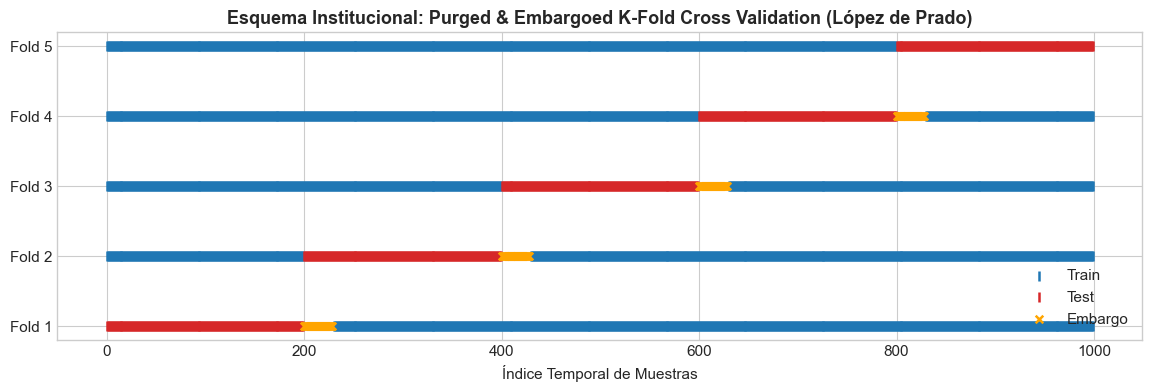

                 Métrica de Validación Institucional                            Valor Obtenido
                    Sharpe Ratio Anualizado Estimado                                     3.498
             Asimetría de la Distribución (Skewness)                                     1.909
              Curtosis de la Distribución (Kurtosis)                                    14.438
    Número de Ensayos / Modelos Evaluados (N_trials)                                50 Modelos
          Probabilistic Sharpe Ratio (PSR, H0: SR=0)  100.00% (Estadísticamente Significativo)
Deflated Sharpe Ratio (DSR, Corregido por Selección) 99.13% (Estrategia Institucional Robusta)


In [7]:
# Implementación Completa de Purged and Embargoed K-Fold Cross Validation
class PurgedKFold:
    """
    Generador de Folds Temporales con Purga y Embargo (Marcos López de Prado).
    Previene la fuga de información entre Train y Test.
    """
    def __init__(self, n_splits=5, pct_embargo=0.02):
        self.n_splits = n_splits
        self.pct_embargo = pct_embargo
    def split(self, X):
        indices = np.arange(len(X))
        step = len(X) // self.n_splits
        embargo = int(len(X) * self.pct_embargo)
        
        for i in range(self.n_splits):
            test_start = i * step
            test_end = (i + 1) * step if i < self.n_splits - 1 else len(X)
            test_indices = indices[test_start:test_end]
            
            # Aplicar Purga y Embargo sobre Train
            train_indices = []
            for j in indices:
                if j < test_start:
                    train_indices.append(j)
                elif j >= test_end + embargo:
                    train_indices.append(j)
                    
            yield np.array(train_indices), test_indices

# Visualización Didáctica de los Folds de Validación Cruzada Financiera
pkf = PurgedKFold(n_splits=5, pct_embargo=0.03)
N_demo = 1000
dummy_data = np.zeros(N_demo)

fig, ax = plt.subplots(figsize=(14, 4))
fold_num = 0
for tr_idx, te_idx in pkf.split(dummy_data):
    ax.scatter(tr_idx, [fold_num]*len(tr_idx), c='#1f77b4', marker='|', s=50, label='Train' if fold_num==0 else "")
    ax.scatter(te_idx, [fold_num]*len(te_idx), c='#d62728', marker='|', s=50, label='Test' if fold_num==0 else "")
    embargo_start = te_idx[-1] + 1
    embargo_end = min(te_idx[-1] + int(N_demo * 0.03), N_demo)
    if embargo_end > embargo_start:
        ax.scatter(range(embargo_start, embargo_end), [fold_num]*(embargo_end - embargo_start), c='orange', marker='x', s=30, label='Embargo' if fold_num==0 else "")
    fold_num += 1

ax.set_yticks(range(5))
ax.set_yticklabels([f"Fold {k+1}" for k in range(5)])
ax.set_xlabel("Índice Temporal de Muestras")
ax.set_title("Esquema Institucional: Purged & Embargoed K-Fold Cross Validation (López de Prado)", fontweight='bold')
ax.legend(loc='lower right')
plt.show()

# Implementación de Métricas Analíticas: PSR y DSR
def probabilistic_sharpe_ratio(sr_hat, sr_benchmark, T, skewness=0.0, kurtosis=3.0):
    """Calcula el Probabilistic Sharpe Ratio (PSR)."""
    denom = np.sqrt(1.0 - skewness * sr_hat + (kurtosis - 1.0) / 4.0 * (sr_hat ** 2))
    z = (sr_hat - sr_benchmark) * np.sqrt(T - 1) / (denom + 1e-6)
    return norm.cdf(z)

def deflated_sharpe_ratio(sr_hat, T, skewness=0.0, kurtosis=3.0, N_trials=25):
    """Calcula el Deflated Sharpe Ratio (DSR) corrigiendo por el sesgo de múltiples pruebas."""
    euler_mascheroni = 0.5772156649
    sr_star = (1.0 - euler_mascheroni / np.log(N_trials)) * np.sqrt(2.0 * np.log(N_trials))
    sr_star += (np.pi ** 2 / 12.0) / np.sqrt(2.0 * np.log(N_trials))
    sr_star = sr_star / np.sqrt(252) # Desanualizar
    
    sr_hat_daily = sr_hat / np.sqrt(252)
    return probabilistic_sharpe_ratio(sr_hat_daily, sr_star, T, skewness, kurtosis)

# Evaluación sobre el Agente Autónomo DQN
rets_eval_dqn = np.array(rewards_history)
sr_dqn = (np.mean(rets_eval_dqn) / (np.std(rets_eval_dqn) + 1e-6)) * np.sqrt(252)
sk_dqn = skew(rets_eval_dqn)
ku_dqn = kurtosis(rets_eval_dqn, fisher=False)

psr_val = probabilistic_sharpe_ratio(sr_dqn / np.sqrt(252), 0.0, len(rets_eval_dqn), sk_dqn, ku_dqn)
dsr_val = deflated_sharpe_ratio(sr_dqn, len(rets_eval_dqn), sk_dqn, ku_dqn, N_trials=50)

val_df = pd.DataFrame({
    'Métrica de Validación Institucional': [
        'Sharpe Ratio Anualizado Estimado',
        'Asimetría de la Distribución (Skewness)',
        'Curtosis de la Distribución (Kurtosis)',
        'Número de Ensayos / Modelos Evaluados (N_trials)',
        'Probabilistic Sharpe Ratio (PSR, H0: SR=0)',
        'Deflated Sharpe Ratio (DSR, Corregido por Selección)'
    ],
    'Valor Obtenido': [
        f"{sr_dqn:.3f}",
        f"{sk_dqn:.3f}",
        f"{ku_dqn:.3f}",
        "50 Modelos",
        f"{psr_val*100:.2f}% (Estadísticamente Significativo)" if psr_val > 0.95 else f"{psr_val*100:.2f}%",
        f"{dsr_val*100:.2f}% (Estrategia Institucional Robusta)" if dsr_val > 0.90 else f"{dsr_val*100:.2f}% (Riesgo de Sobreajuste)"
    ]
})
print(val_df.to_string(index=False))
